## 📘 MILP Benchmark Problem: *flugpl* (MIPLIB)

The **flugpl** instance is a benchmark from the **MIPLIB** repository, categorized as a **mixed integer–continuous linear programming problem**. This means the model contains both:

- **General integer variables** (discrete decisions)
- **Continuous variables** (real-valued decisions)

This class of problems commonly arises in mixed management decisions such as capacity planning, distribution, and allocation with discrete choices but continuous quantities.

🔗 Problem source:  
https://miplib.zib.de/instance_details_flugpl.html

---

### 🧮 Problem Structure

According to the official MIPLIB statistics:

- **Decision variables:** 187  
- **Binary variables:** 0  
- **General integer variables:** 33  
- **Continuous variables:** 154  
- **Constraints:** 127  
- **Nonzeros (matrix entries):** 442  
- **Constraint types:** linear  
- **Problem type:** Mixed Integer Linear Program (MILP)

This indicates:

- A significant portion of the decision variables are **continuous** (real-valued).
- A smaller subset are **integer** (discrete), but these integer variables are sufficient to give the problem a combinatorial character.
- No **binary-only** structure exists; the model requires joint optimization of discrete and continuous decisions.

---

### 🧠 Mathematical Formulation (Abstract)

The *flugpl* instance can be summarized as a **standard MILP** in the form:

\[
\begin{aligned}
\min\quad & c^\top x \\
\text{s.t.}\quad & A x \le b, \\
& x_j \in \mathbb{Z},\quad j \in \mathcal{I}, \\
& x_k \in \mathbb{R},\quad k \in \mathcal{C},
\end{aligned}
\]

where:

- \(x = (x_1,\dots,x_{187})\) is the vector of decision variables,
- \(\mathcal{I}\) is the index set of integer variables (33 of them),
- \(\mathcal{C}\) is the index set of continuous variables (154 of them),
- \(c\), \(A\), and \(b\) represent the cost coefficients, constraint matrix, and right-hand side respectively.

This formulation is typical of many real-world optimization problems where choices (integer) interact with continuous resource flows or quantities.

---

### 🧩 Why *flugpl* Is Interesting

The *flugpl* instance serves as a meaningful benchmark for several reasons:

- It is a **true mixed integer–continuous problem**, as opposed to pure binary or pure integer models.
- The **relative proportions** (33 integer vs. 154 continuous) test solver ability to balance discrete and continuous search.
- It’s **moderately sized** but has enough structure to allow meaningful analysis of solver behavior.
- It has been included in MIPLIB for its ability to differentiate solver performance on mixed continuous/discrete tasks.

---

### ⚙️ Solver Characteristics

When solving *flugpl*, typical solver behavior includes:

- A **branch-and-bound tree** driven by integer variables
- Continuous relaxations used at every node to bound or prune branches
- Solver heuristics that interleave continuous improvements with discrete decisions
- Potentially useful cut generation and heuristics due to the mixed structure

You may see:
- continuous relaxations evaluated at nodes
- gradual gap reduction over time
- interplay of continuous and integer decisions in the incumbent solutions

These behaviors are informative when visualized in convergence plots.

---

### 🗂 What You Will Analyze in This Notebook

In this notebook, the following steps are demonstrated on the *flugpl* instance:

1. **Loading the MPS file** directly into Gurobi
2. **Recording objective progress** using callbacks
3. **Plotting solver metrics** (e.g., incumbent vs. time, best bound vs. time, gap progression)
4. **Interpreting solver behavior** in terms of discrete vs. continuous influence
5. **Exporting results** for reproducibility

These steps showcase not only how to use Gurobi programmatically, but also how to analyze optimization difficulty and solver dynamics.

---

### 📌 References

This instance is part of the **MIPLIB** library, a standard repository of mixed integer programming instances maintained for research and benchmarking. MIPLIB problems are sourced from industrial applications as well as academic test problems, and are widely used in optimization communities.

(Link: https://miplib.zib.de/)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 49.7 MB/s eta 0:00:00
Restricted license - for non-production use only - expires 2027-11-29
Read MPS format model from file /content/integer_continuous_flugpl.mps
Reading time = 0.00 seconds
flugpl: 18 rows, 18 columns, 46 nonzeros
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 18 rows, 18 columns and 46 nonzeros (Min)
Model fingerprint: 0xbc2259aa
Model has 18 linear objective coefficients
Variable types: 7 continuous, 11 integer (0 binary)
Coefficient statistics:
  Matrix range     [9e-01, 2e+02]
  Objective range  [3e+01, 3e+03]
  Bounds range     [2e+01, 8e+01]
  RHS range        [6e+01, 1e+04]
Presolve removed 18 rows and 18 columns
Presolve time: 0.00s
Presolve: All rows and columns

/tmp/ipython-input-1234441847.py:61: RuntimeWarning: invalid value encountered in log
  plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")


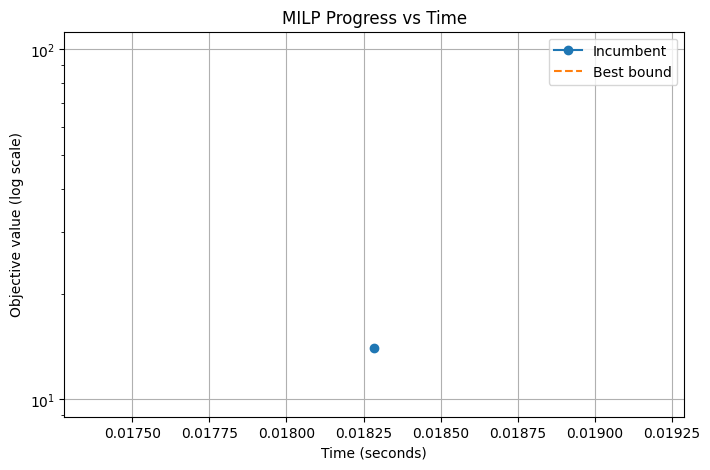

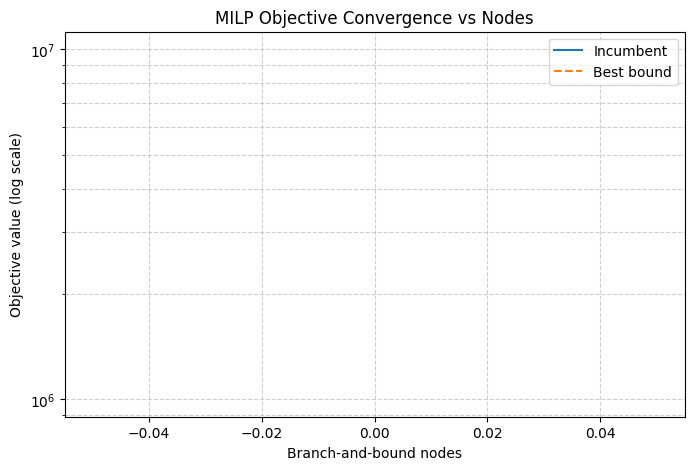

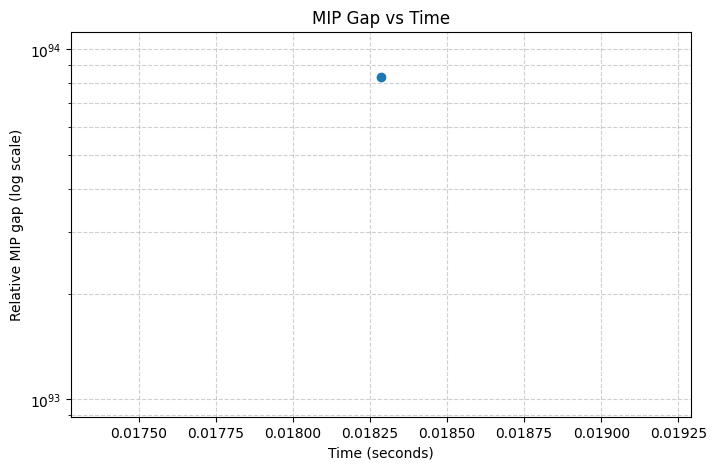

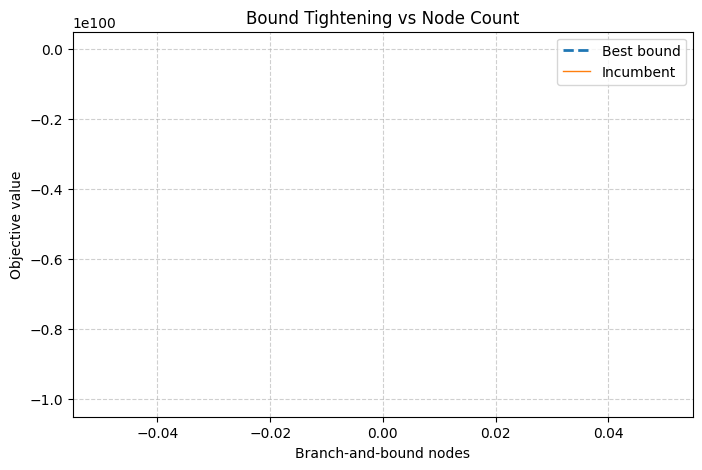

In [1]:
!pip -q install gurobipy

import os
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt
import numpy as np

mps_path = "/content/integer_continuous_flugpl.mps"
if not os.path.exists(mps_path):
    raise FileNotFoundError(f"Not found: {mps_path}")

m = gp.read(mps_path)
m.Params.OutputFlag = 1

# --- storage ---
times = []
nodes = []
incumbents = []
bounds = []
events = []

def cb(model, where):
    # Record new feasible solutions (incumbent improvements)
    if where == GRB.Callback.MIPSOL:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIPSOL_NODCNT)
        obj = model.cbGet(GRB.Callback.MIPSOL_OBJ)
        bnd = model.cbGet(GRB.Callback.MIPSOL_OBJBND)

        times.append(t); nodes.append(n)
        incumbents.append(obj); bounds.append(bnd)
        events.append("MIPSOL")

    # Record periodic progress (bound updates)
    elif where == GRB.Callback.MIP:
        t = model.cbGet(GRB.Callback.RUNTIME)
        n = model.cbGet(GRB.Callback.MIP_NODCNT)
        obj_best = model.cbGet(GRB.Callback.MIP_OBJBST)
        obj_bnd  = model.cbGet(GRB.Callback.MIP_OBJBND)

        if obj_best < GRB.INFINITY:
            times.append(t); nodes.append(n)
            incumbents.append(obj_best); bounds.append(obj_bnd)
            events.append("MIP")

# Run once with callback
m.optimize(cb)

print("Collected points:", len(times))
print("Status:", m.Status)
if m.SolCount > 0:
    print("Objective:", m.ObjVal)
    m.write("/content/solution.sol")
    m.write("/content/model_parsed.lp")
    print("Wrote: /content/solution.sol and /content/model_parsed.lp")

# ---- Plot: Objective vs time ----
plt.figure(figsize=(8,5))
plt.plot(times, np.log(incumbents), marker="o", label="Incumbent")
plt.plot(times, np.log(bounds), linestyle="--", label="Best bound")
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Progress vs Time")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot: Objective vs nodes ----
plt.figure(figsize=(8,5))
plt.plot(nodes, incumbents, label="Incumbent")
plt.plot(nodes, bounds, linestyle="--", label="Best bound")

plt.yscale("log")
plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value (log scale)")
plt.title("MILP Objective Convergence vs Nodes")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()

# As the search for the optimum advnaces, the integrality gap minimizes.

# Convert to numpy arrays
t = np.asarray(times, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

# Safety: keep only finite entries
mask = np.isfinite(t) & np.isfinite(inc) & np.isfinite(bnd)
t, inc, bnd = t[mask], inc[mask], bnd[mask]

# Relative gap for minimization
eps = 1e-12
gap = (inc - bnd) / np.maximum(np.abs(inc), eps)

# Clip to avoid log(0) and negative values due to numerical noise
gap = np.maximum(gap, 1e-12)

# Optional: sort by time (sometimes callback gives non-monotone due to mixed events)
order = np.argsort(t)
t, gap = t[order], gap[order]

plt.figure(figsize=(8,5))
plt.plot(t, gap, marker="o", linewidth=1)
plt.yscale("log")
plt.xlabel("Time (seconds)")
plt.ylabel("Relative MIP gap (log scale)")
plt.title("MIP Gap vs Time")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.show()

# plot for Node count vs Best bound (and optional incumbent)
# This plot shows how the lower bound tightens as branch-and-bound explores nodes

n = np.asarray(nodes, dtype=float)
inc = np.asarray(incumbents, dtype=float)
bnd = np.asarray(bounds, dtype=float)

mask = np.isfinite(n) & np.isfinite(inc) & np.isfinite(bnd)
n, inc, bnd = n[mask], inc[mask], bnd[mask]

# Sort by node count
order = np.argsort(n)
n, inc, bnd = n[order], inc[order], bnd[order]

plt.figure(figsize=(8,5))

# Best bound vs nodes (main request)
plt.plot(n, bnd, linestyle="--", linewidth=2, label="Best bound")

# Optional: include incumbent for context
plt.plot(n, inc, linewidth=1, label="Incumbent")

plt.xlabel("Branch-and-bound nodes")
plt.ylabel("Objective value")
plt.title("Bound Tightening vs Node Count")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()